In [ ]:
import os
HOME = os.getcwd()
print(HOME)

d:\experimen


In [ ]:
import torch
# !nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)

# import roboflow
import supervision
import transformers
import pytorch_lightning

print(
    # "roboflow:", roboflow.__version__,
    "; supervision:", supervision.__version__,
    "; transformers:", transformers.__version__,
    "; pytorch_lightning:", pytorch_lightning.__version__
)

torch:  2.1 ; cuda:  cu118


c:\Users\Andrian Rakhmatsyah\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


; supervision: 0.3.0 ; transformers: 4.35.0 ; pytorch_lightning: 2.1.0


In [ ]:
import torch
from transformers import DetrForObjectDetection, DetrImageProcessor


# settings
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = 'facebook/detr-resnet-50'
CONFIDENCE_TRESHOLD = 0.5
image_processor = DetrImageProcessor.from_pretrained(CHECKPOINT)

c:\Users\Andrian Rakhmatsyah\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Andrian Rakhmatsyah\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `siz

In [ ]:
import os
import torchvision

dataset='D:\experimen\WhiteBloodCell_deformable'

# configuration
ANNOTATION_FILE_NAME = "_annotations.coco.json"
TRAIN_DIRECTORY = os.path.join(dataset, "train")
VAL_DIRECTORY = os.path.join(dataset, "valid")
TEST_DIRECTORY = os.path.join(dataset, "test")

class CocoDetection(torchvision.datasets.CocoDetection):
    def __init__(
        self,
        image_directory_path: str,
        image_processor,
        train: bool = True
    ):
        annotation_file_path = os.path.join(image_directory_path, ANNOTATION_FILE_NAME)
        super(CocoDetection, self).__init__(image_directory_path, annotation_file_path)
        self.image_processor = image_processor

    def __getitem__(self, idx):
        images, annotations = super(CocoDetection, self).__getitem__(idx)
        image_id = self.ids[idx]
        annotations = {'image_id': image_id, 'annotations': annotations}
        encoding = self.image_processor(images=images, annotations=annotations, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze()
        target = encoding["labels"][0]

        return pixel_values, target


TRAIN_DATASET = CocoDetection(
    image_directory_path=TRAIN_DIRECTORY,
    image_processor=image_processor,
    train=True)
VAL_DATASET = CocoDetection(
    image_directory_path=VAL_DIRECTORY,
    image_processor=image_processor,
    train=False)
TEST_DATASET = CocoDetection(
    image_directory_path=TEST_DIRECTORY,
    image_processor=image_processor,
    train=False)

print("Number of training examples:", len(TRAIN_DATASET))
print("Number of validation examples:", len(VAL_DATASET))
print("Number of test examples:", len(TEST_DATASET))

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Number of training examples: 1213
Number of validation examples: 100
Number of test examples: 76


Image #832


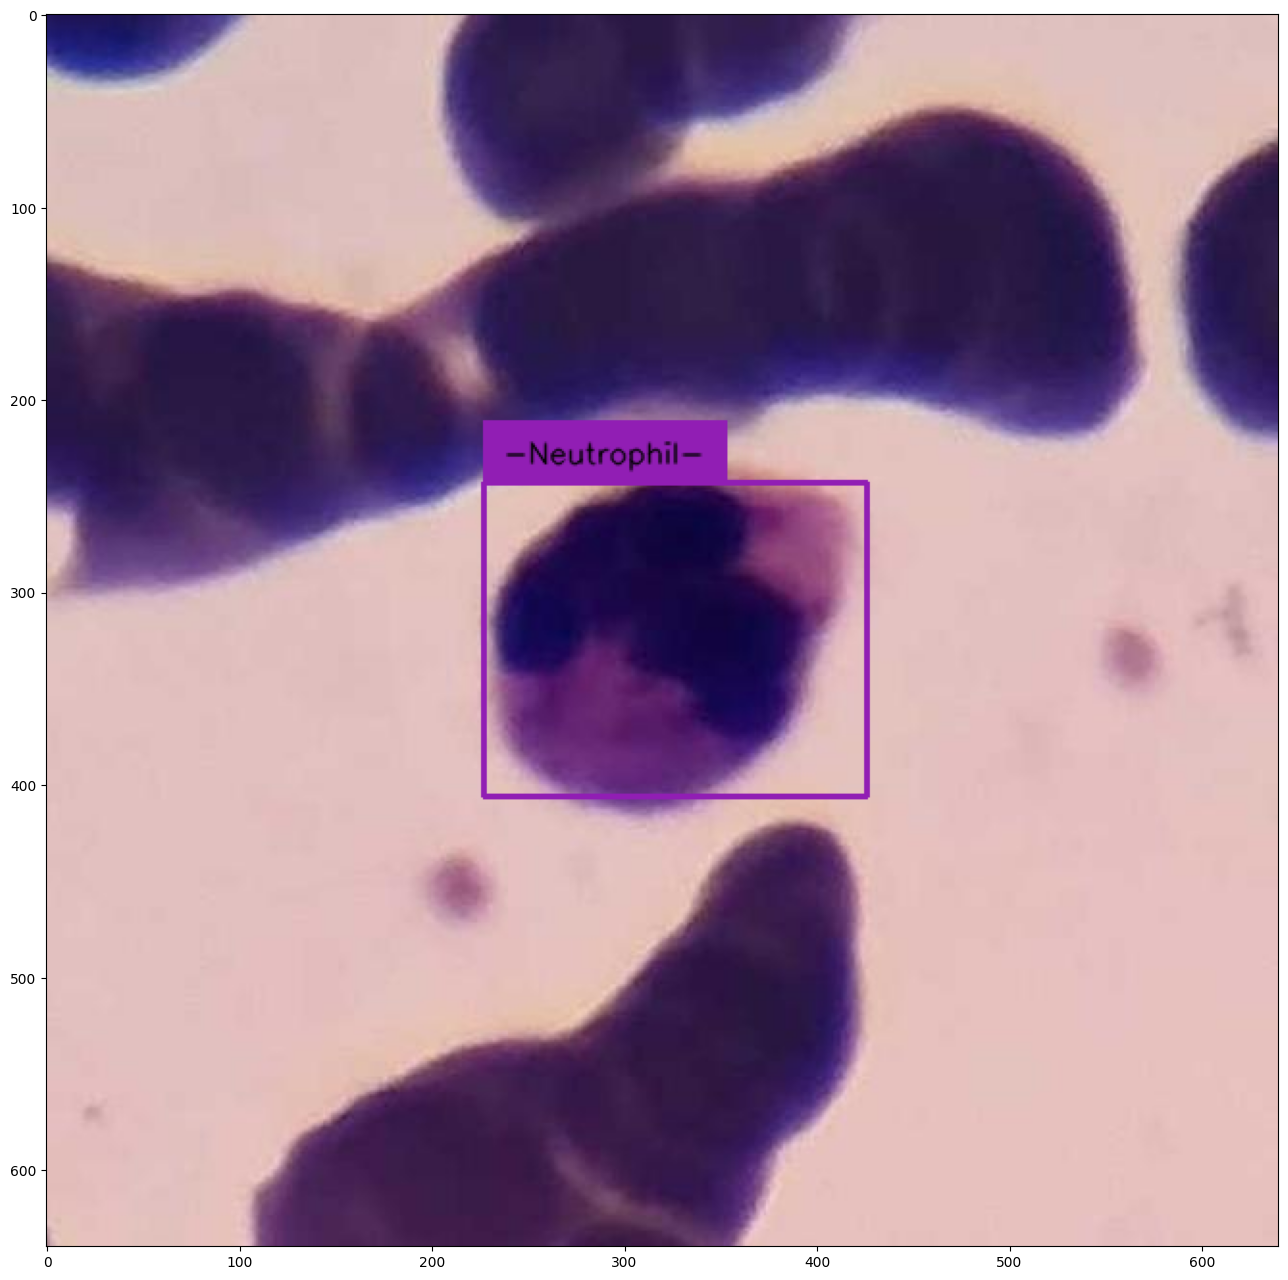

In [ ]:
import random
import cv2
import numpy as np
import supervision as sv


# select random image
image_ids = TRAIN_DATASET.coco.getImgIds()
image_id = random.choice(image_ids)
print('Image #{}'.format(image_id))

# load image and annotatons
image = TRAIN_DATASET.coco.loadImgs(image_id)[0]
annotations = TRAIN_DATASET.coco.imgToAnns[image_id]
image_path = os.path.join(TRAIN_DATASET.root, image['file_name'])
image = cv2.imread(image_path)

# annotate
detections = sv.Detections.from_coco_annotations(coco_annotation=annotations)

# we will use id2label function for training
categories = TRAIN_DATASET.coco.cats
id2label = {k: v['name'] for k,v in categories.items()}

labels = [
    f"{id2label[class_id]}"
    for _, _, class_id, _
    in detections
]

box_annotator = sv.BoxAnnotator()
frame = box_annotator.annotate(scene=image, detections=detections, labels=labels)

%matplotlib inline
sv.show_frame_in_notebook(image, (16, 16))

In [ ]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    # DETR authors employ various image sizes during training, making it not possible
    # to directly batch together images. Hence they pad the images to the biggest
    # resolution in a given batch, and create a corresponding binary pixel_mask
    # which indicates which pixels are real/which are padding
    pixel_values = [item[0] for item in batch]
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item[1] for item in batch]
    return {
        'pixel_values': encoding['pixel_values'],
        'pixel_mask': encoding['pixel_mask'],
        'labels': labels
    }

TRAIN_DATALOADER = DataLoader(dataset=TRAIN_DATASET, collate_fn=collate_fn, batch_size=4, shuffle=True)
VAL_DATALOADER = DataLoader(dataset=VAL_DATASET, collate_fn=collate_fn, batch_size=4)
TEST_DATALOADER = DataLoader(dataset=TEST_DATASET, collate_fn=collate_fn, batch_size=4)

In [ ]:
import pytorch_lightning as pl
from transformers import DetrForObjectDetection
import torch


class Detr(pl.LightningModule):

    def __init__(self, lr, lr_backbone, weight_decay):
        super().__init__()
        self.model = DetrForObjectDetection.from_pretrained(
            pretrained_model_name_or_path=CHECKPOINT,
            num_labels=len(id2label),
            ignore_mismatched_sizes=True
        )

        self.lr = lr
        self.lr_backbone = lr_backbone
        self.weight_decay = weight_decay

    def forward(self, pixel_values, pixel_mask):
        return self.model(pixel_values=pixel_values, pixel_mask=pixel_mask)

    def common_step(self, batch, batch_idx):
        pixel_values = batch["pixel_values"]
        pixel_mask = batch["pixel_mask"]
        labels = [{k: v.to(self.device) for k, v in t.items()} for t in batch["labels"]]

        outputs = self.model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)

        loss = outputs.loss
        loss_dict = outputs.loss_dict

        return loss, loss_dict

    def training_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)
        # logs metrics for each training_step, and the average across the epoch
        self.log("training_loss", loss)
        for k,v in loss_dict.items():
            self.log("train_" + k, v.item())

        return loss

    def validation_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)
        self.log("validation/loss", loss)
        for k, v in loss_dict.items():
            self.log("validation_" + k, v.item())

        return loss

    def configure_optimizers(self):
        param_dicts = [
            {
                "params": [p for n, p in self.named_parameters() if "backbone" not in n and p.requires_grad]},
            {
                "params": [p for n, p in self.named_parameters() if "backbone" in n and p.requires_grad],
                "lr": self.lr_backbone,
            },
        ]
        return torch.optim.AdamW(param_dicts, lr=self.lr, weight_decay=self.weight_decay)

    def train_dataloader(self):
        return TRAIN_DATALOADER

    def val_dataloader(self):
        return VAL_DATALOADER

In [ ]:
model = Detr(lr=1e-4, lr_backbone=1e-5, weight_decay=1e-4)

batch = next(iter(TRAIN_DATALOADER))
outputs = model(pixel_values=batch['pixel_values'], pixel_mask=batch['pixel_mask'])

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were not initialized from the model checkpoin

In [ ]:
outputs.logits.shape

torch.Size([4, 100, 7])

In [ ]:
from pytorch_lightning import Trainer

%cd {HOME}

# settings
MAX_EPOCHS = 50

# pytorch_lightning < 2.0.0
# trainer = Trainer(gpus=1, max_epochs=MAX_EPOCHS, gradient_clip_val=0.1, accumulate_grad_batches=8, log_every_n_steps=5)

# pytorch_lightning >= 2.0.0
trainer = Trainer(devices=1, accelerator="gpu", max_epochs=MAX_EPOCHS, gradient_clip_val=0.1, accumulate_grad_batches=8, log_every_n_steps=5)

trainer.fit(model)


C:\Users\Andrian Rakhmatsyah\AppData\Roaming\Python\Python310\site-packages\IPython\core\magics\osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
c:\Users\Andrian Rakhmatsyah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:67: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA 

d:\experimen


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type                   | Params
-------------------------------------------------
0 | model | DetrForObjectDetection | 41.5 M
-------------------------------------------------
41.3 M    Trainable params
222 K     Non-trainable params
41.5 M    Total params
166.012   Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Andrian Rakhmatsyah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


...

c:\Users\Andrian Rakhmatsyah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\utilities\data.py:77: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 4. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


c:\Users\Andrian Rakhmatsyah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


Epoch 49: 100%|██████████| 304/304 [01:21<00:00,  3.73it/s, v_num=5]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 304/304 [01:24<00:00,  3.59it/s, v_num=5]


In [ ]:
model.to(DEVICE)

Detr(
  (model): DetrForObjectDetection(
    (model): DetrModel(
      (backbone): DetrConvModel(
        (conv_encoder): DetrConvEncoder(
          (model): FeatureListNet(
            (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
            (bn1): DetrFrozenBatchNorm2d()
            (act1): ReLU(inplace=True)
            (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
            (layer1): Sequential(
              (0): Bottleneck(
                (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (bn1): DetrFrozenBatchNorm2d()
                (act1): ReLU(inplace=True)
                (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                (bn2): DetrFrozenBatchNorm2d()
                (drop_block): Identity()
                (act2): ReLU(inplace=True)
                (aa): Identity()
                (conv3): Conv2d(64, 256

In [ ]:
MODEL_PATH = os.path.join(HOME, 'DETR_WBC')
model.model.save_pretrained(MODEL_PATH)

In [ ]:
MODEL_PATH = os.path.join(HOME, 'DETR_WBC')
model = DetrForObjectDetection.from_pretrained(MODEL_PATH)
if torch.cuda.is_available():
    model.cuda()

Image #27
ground truth


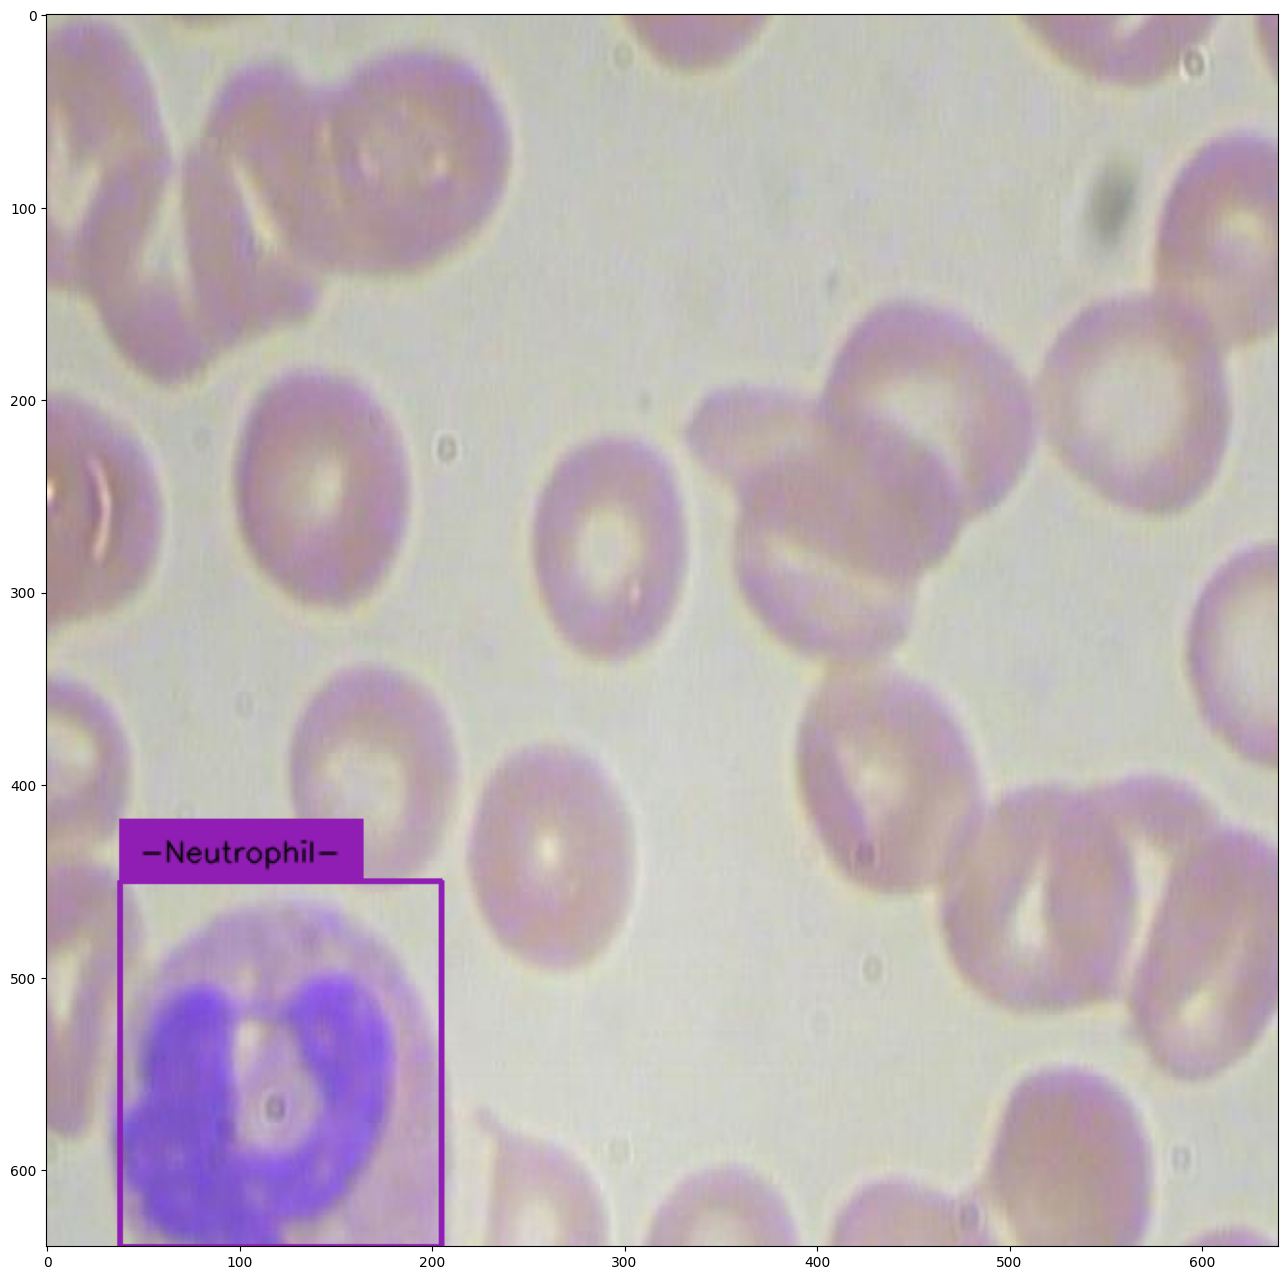

detections


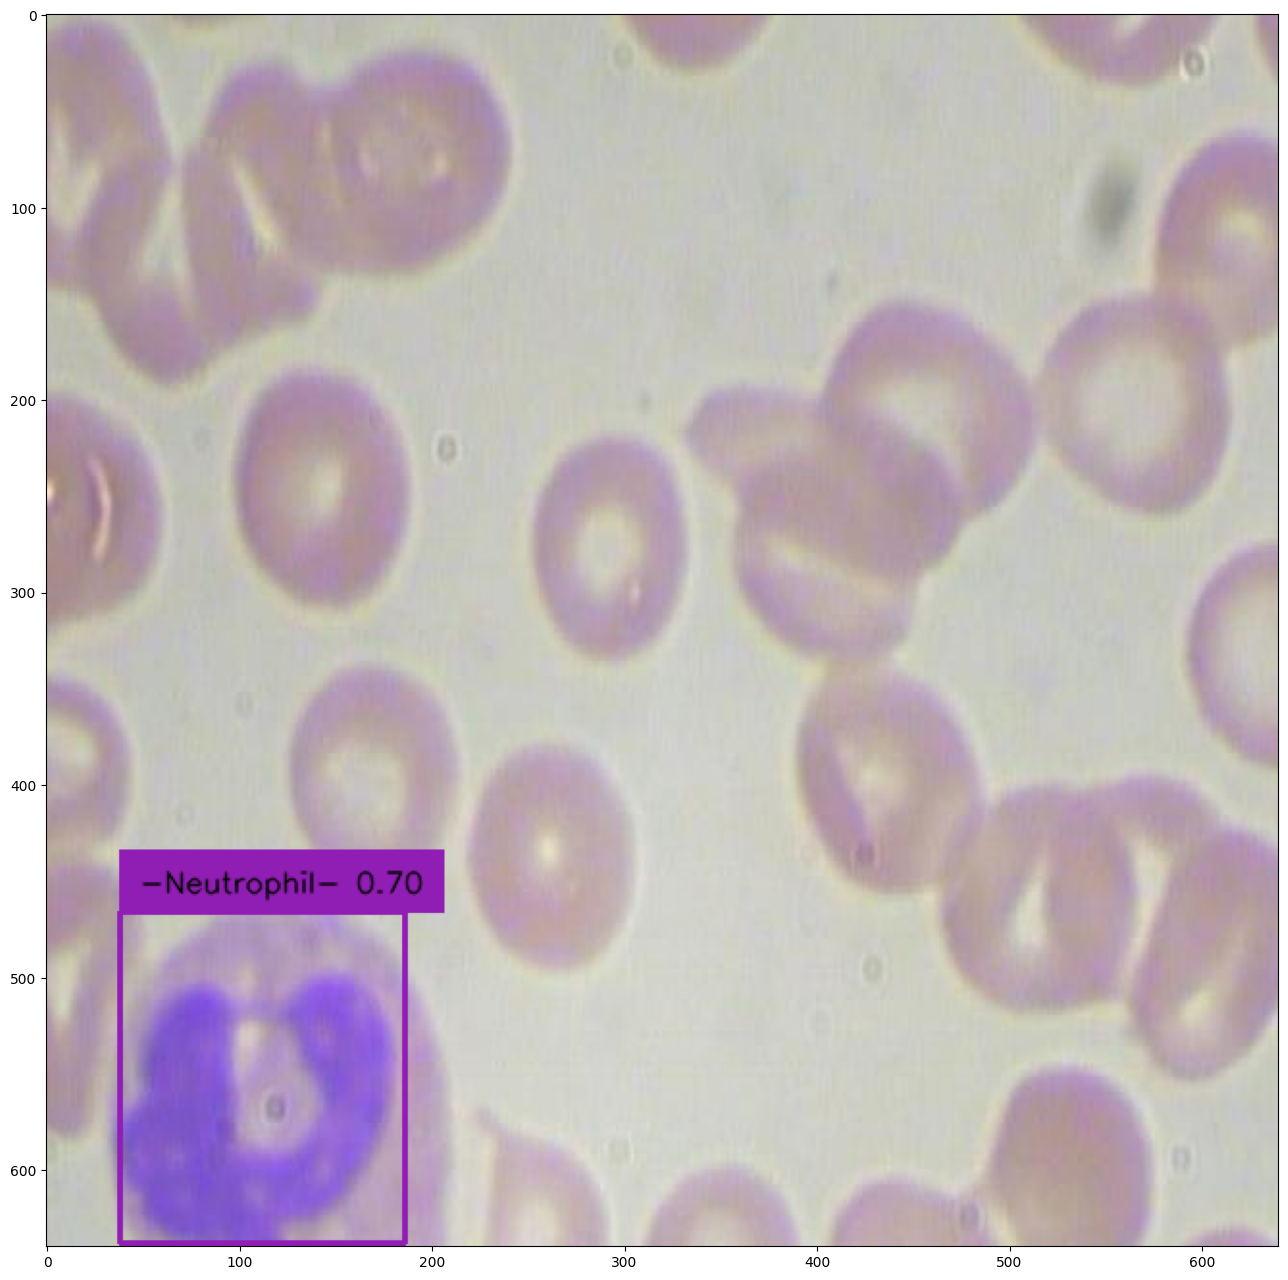

In [ ]:
import random
import cv2
import numpy as np
import supervision as sv


# utils
categories = TEST_DATASET.coco.cats
id2label = {k: v['name'] for k,v in categories.items()}
box_annotator = sv.BoxAnnotator()

# select random image
image_ids = TEST_DATASET.coco.getImgIds()
image_id = random.choice(image_ids)
print('Image #{}'.format(image_id))

# load image and annotatons
image = TEST_DATASET.coco.loadImgs(image_id)[0]
annotations = TEST_DATASET.coco.imgToAnns[image_id]
image_path = os.path.join(TEST_DATASET.root, image['file_name'])
image = cv2.imread(image_path)

# annotate
detections = sv.Detections.from_coco_annotations(coco_annotation=annotations)
labelsGT = [f"{id2label[class_id]}" for _, _, class_id, _ in detections]
frame = box_annotator.annotate(scene=image.copy(), detections=detections, labels=labelsGT)

print('ground truth')
%matplotlib inline
sv.show_frame_in_notebook(frame, (20, 16))

# inference
with torch.no_grad():

    # load image and predict
    inputs = image_processor(images=image, return_tensors='pt').to(DEVICE)
    outputs = model(**inputs)

    # post-process
    target_sizes = torch.tensor([image.shape[:2]]).to(DEVICE)
    results = image_processor.post_process_object_detection(
        outputs=outputs,
        threshold=CONFIDENCE_TRESHOLD,
        target_sizes=target_sizes
    )[0]

# annotate
detections = sv.Detections.from_transformers(transformers_results=results).with_nms(threshold=0.5)
labelsPD = [f"{id2label[class_id]} {confidence:.2f}" for _, confidence, class_id, _ in detections]
frame = box_annotator.annotate(scene=image.copy(), detections=detections, labels=labelsPD)

print('detections')
%matplotlib inline
sv.show_frame_in_notebook(frame, (16, 16))

In [ ]:
results

{'scores': tensor([0.9924], device='cuda:0'),
 'labels': tensor([2], device='cuda:0'),
 'boxes': tensor([[189.7334, 137.9927, 485.2570, 480.9700]], device='cuda:0')}

In [ ]:
target_sizes

tensor([[640, 640]], device='cuda:0')

In [ ]:
len(outputs)

4

In [ ]:
inputs

{'pixel_values': tensor([[[[ 0.4166,  0.3994,  0.3823,  ...,  0.1426,  0.1426,  0.1426],
          [ 0.3994,  0.3823,  0.3652,  ...,  0.1426,  0.1426,  0.1426],
          [ 0.3823,  0.3652,  0.3481,  ...,  0.1597,  0.1597,  0.1597],
          ...,
          [ 0.3652,  0.3481,  0.3309,  ...,  0.7591,  0.7419,  0.7419],
          [ 0.3652,  0.3481,  0.3309,  ...,  0.7591,  0.7419,  0.7419],
          [ 0.3652,  0.3481,  0.3309,  ...,  0.7762,  0.7591,  0.7419]],

         [[ 0.0476,  0.0301,  0.0126,  ..., -1.0903, -1.0903, -1.0903],
          [ 0.0301,  0.0126, -0.0049,  ..., -1.0903, -1.0903, -1.0903],
          [ 0.0126, -0.0049, -0.0224,  ..., -1.0728, -1.0728, -1.0728],
          ...,
          [ 0.0476,  0.0301,  0.0126,  ...,  1.0455,  1.0280,  1.0280],
          [ 0.0476,  0.0301,  0.0126,  ...,  1.0455,  1.0280,  1.0280],
          [ 0.0476,  0.0301,  0.0126,  ...,  1.0630,  1.0455,  1.0280]],

         [[ 1.1411,  1.1237,  1.1062,  ...,  1.1934,  1.1934,  1.1934],
          [ 1

In [ ]:
#ground truth
i=0
listofann =[]
while i < len (TEST_DATASET):
  if i == 11 or i == 36 or i == 41 or i == 54:
    i += 1
  ann=TEST_DATASET.coco.loadAnns(i)
  test = ann[0]
  # valANNO = []
  # valANNO.append(test['bbox'][0])
  # valANNO.append(test['bbox'][1])
  # valANNO.append(test['bbox'][2])
  # valANNO.append(test['bbox'][3])
  listofann.append(TEST_DATASET.coco.loadCats(test['category_id'])[0]['name'])
  # listofann.append(valANNO)
  i+=1
print(listofann[66])
print(len(listofann))
# ann=TEST_DATASET.coco.loadAnns(0)
# test = ann[0]
# print(TEST_DATASET.coco.loadCats(test['category_id'])[0]['name'])
# print(TEST_DATASET.coco.loadCats(3)[0]['name'])

-Monocyte-
72


In [ ]:
#Prediction
listofpred = []
i = 0
while i < len(TEST_DATASET):
  if i == 11 or i == 36 or i == 41 or i == 54:
    i += 1
  image = TEST_DATASET.coco.loadImgs(i)[0]
  image_path = os.path.join(TEST_DATASET.root, image['file_name'])
  image = cv2.imread(image_path)
  with torch.no_grad():

      # load image and predict
      inputs = image_processor(images=image, return_tensors='pt').to(DEVICE)
      outputs = model(**inputs)

      # post-process
      target_sizes = torch.tensor([image.shape[:2]]).to(DEVICE)
      results = image_processor.post_process_object_detection(
          outputs=outputs,
          threshold=CONFIDENCE_TRESHOLD,
          target_sizes=target_sizes
      )[0]
  detections = sv.Detections.from_transformers(transformers_results=results).with_nms(threshold=0.5)


  # pred = np.array([])
  # pred = np.append(pred, detections.xyxy[0])
  # pred = np.append(pred, detections.confidence[0])
  # pred = np.append(pred, detections.class_id[0])
  listofpred.append(TEST_DATASET.coco.loadCats(detections.class_id)[0]['name'])
  # pred = pred.tolist()
  # listofpred.append(pred)
  i += 1

print(listofpred)
print(len(listofpred))
# img = TEST_DATASET.coco.loadImgs(11)[0]
# print(img)
#Error img
#11 : 'BloodImage_00232_jpg.rf.02d13031804fd7d7a48f67010b4d123d.jpg'
#27 : 'BloodImage_00362_jpg.rf.55d7c533e4414e252f4da73f23ebde00.jpg'(re check) (ok)
#36 : 'BloodImage_00362_jpg.rf.55d7c533e4414e252f4da73f23ebde00.jpg'
#41 : 'BloodImage_00313_jpg.rf.7f619b2aa57c8b36686c2d17fcfd251b.jpg'
#42 : '95-8-6-1_365_1_jpg.rf.90c4ec100da23f91c7b4f41ab786f2f4.jpg' (re check) (ok)
#44 : 'BloodImage_00350_jpg.rf.80a285f21a7c97d5baab604ac5502386.jpg' (re check) (ok)
#54 : 'BloodImage_00379_jpg.rf.b5427079fe4892d59e287a99b4836fc3.jpg'
#64 : '95-8-6-1_356_3_jpg.rf.da034bb2ca33ced0219bc2e5f40e5b03.jpg' (re check) (ok)

['-Eosinophil-', '-Eosinophil-', '-Eosinophil-', '-Lymphocyte-', '-Lymphocyte-', '-Basophil-', '-Eosinophil-', '-Eosinophil-', '-Neutrophil-', '-Neutrophil-', '-Neutrophil-', '-Eosinophil-', '-Eosinophil-', '-Lymphocyte-', '-Lymphocyte-', '-Eosinophil-', '-Monocyte-', '-Lymphocyte-', '-Neutrophil-', '-Eosinophil-', '-Neutrophil-', '-Eosinophil-', '-Eosinophil-', '-Basophil-', '-Eosinophil-', '-Monocyte-', '-Neutrophil-', '-Lymphocyte-', '-Eosinophil-', '-Basophil-', '-Lymphocyte-', '-Basophil-', '-Neutrophil-', '-Monocyte-', '-Lymphocyte-', '-Basophil-', '-Eosinophil-', '-Neutrophil-', '-Lymphocyte-', '-Monocyte-', '-Neutrophil-', '-Neutrophil-', '-Neutrophil-', '-Lymphocyte-', '-Basophil-', '-Eosinophil-', '-Eosinophil-', '-Basophil-', '-Neutrophil-', '-Lymphocyte-', '-Eosinophil-', '-Eosinophil-', '-Eosinophil-', '-Neutrophil-', '-Neutrophil-', '-Monocyte-', '-Eosinophil-', '-Eosinophil-', '-Monocyte-', '-Eosinophil-', '-Eosinophil-', '-Eosinophil-', '-Lymphocyte-', '-Basophil-', '-M

In [ ]:
TEST_DATASET.coco.loadImgs(27)[0]

{'id': 27,
 'license': 1,
 'file_name': 'BloodImage_00362_jpg.rf.55d7c533e4414e252f4da73f23ebde00.jpg',
 'height': 640,
 'width': 640,
 'date_captured': '2023-10-21T15:29:47+00:00'}

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn import datasets

y_test = listofann
y_pred = listofpred

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm,
                     index = ['Basophil','Eosinophil','Lymphocyte','Monocyte','Neutrophil'],
                     columns = ['Basophil','Eosinophil','Lymphocyte','Monocyte','Neutrophil'])

plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True)
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()